# Otonom Drone Görüntüleri ile Nesne Tespiti (YOLOv8)

## 1. Proje Tanımı ve Eğitim Hazırlığı
Bu çalışmanın amacı, otonom İHA (Drone) sistemleri için kritik olan nesne tespiti görevini gerçekleştirmektir. Drone kamerasından alınan görüntüler üzerindeki belirli geometrik şekillerin (**Mavi Altıgen, Mavi Kare, Kırmızı Üçgen, Kırmızı Kare**) tespit edilmesi hedeflenmiştir.

### 1.1. Veri Seti Yapısı
Çalışmada kullanılan veri seti, **YOLO formatında** etiketlenmiştir.
* **Eğitim (Train):** Modelin öğrenmesi için kullanılan ana veri grubu.
* **Doğrulama (Validation):** Her epoch sonunda modelin başarısını ölçmek için kullanılan veri grubu.
* **Test:** Modelin eğitim bittikten sonra "gerçek hayat" performansını ölçmek için ayrılan veri grubu.

### 1.2. Eğitim Konfigürasyonu
Eğitim sürecinde **Ultralytics YOLOv8n (Nano)** modeli tercih edilmiştir.
* **Transfer Learning:** Model, COCO ağırlıkları (`yolov8n.pt`) ile başlatılarak bu şekiller için özelleştirilmiştir.
* **Epochs:** 20 (Modelin veri setini turlama sayısı).
* **Image Size:** 640x640 piksel. (standart)

## Modelin Eğitimi

In [ ]:
from ultralytics import YOLO  # YOLOv8 modeli için Ultralytics kütüphanesi
import os  # Dosya yolları ile çalışmak için os modülü

# YOLOv8 modelini yükle
# 'yolov8n.pt': Nano model - hızlı ve hafif, COCO ağırlıkları ile önceden eğitilmiş
model = YOLO('yolov8n.pt')  

# Eğitim veri setinin konfigürasyon dosyasının tam yolunu al
yaml_path = os.path.abspath("yoda_odevlendirme_veriseti.yolov8/data.yaml")

# Hangi veri seti ile eğitim yapılacağını konsola yazdır
print(f"Eğitim şu dosya ile başlayacak: {yaml_path}")

# Modeli eğitim veri seti üzerinde eğit
# data=yaml_path: Veri seti konfigürasyon dosyası
# epochs=20: Model veri setini 20 kez turlaması (deneme amaçlı, gerekirse arttırılabilir)
# imgsz=640: Giriş görüntü boyutu (640x640 piksel - YOLOv8 standart boyutu)
# name='yoda_modeli': Eğitim sonuçlarının kaydedileceği klasör adı
results = model.train(
    data=yaml_path,          # Veri seti yolu
    epochs=20,               # Eğitim turları
    imgsz=640,               # Görüntü boyutu
    name='yoda_modeli'       # Sonuç klasörü adı
)

Eğitim şu dosya ile başlayacak: c:\Users\aydin\Desktop\Yazılım\Git\Aydin_Alizade_YODA_IHA_YAZILIM\Odev_5\yoda_odevlendirme_veriseti.yolov8\data.yaml
Ultralytics 8.3.241  Python-3.11.9 torch-2.9.1+cpu CPU (12th Gen Intel Core i7-12700H)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=c:\Users\aydin\Desktop\Yazlm\Git\Aydin_Alizade_YODA_IHA_YAZILIM\Odev_5\yoda_odevlendirme_veriseti.yolov8\data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_de

## Performans Analizi ve Metrikler
Modelin 20 epoch süren eğitimi tamamlanmış ve elde edilen sonuçlar analiz edilmiştir. Aşağıdaki grafikler modelin başarısını özetlemektedir:

### Metriklerin Anlamları
1.  **Karmaşıklık Matrisi (Confusion Matrix):** Modelin tahminleri ile gerçek sınıflar arasındaki ilişkiyi gösterir. Matrisin köşegeni üzerindeki koyu renkli alanlar, modelin sınıfları birbirine karıştırmadan doğru tespit ettiğini kanıtlar.
2.  **Eğitim Grafikleri (Results):**
    * **Box Loss:** Kutucuk hatasının eğitim boyunca düşmesi, modelin nesne konumlarını daha hassas bulduğunu gösterir.
    * **mAP (Mean Average Precision):** Modelin genel başarı puanıdır. %95 üzerindeki değerler modelin yüksek performans gösterdiğini ifade eder.
3.  **Precision-Recall Eğrisi:** Eğrinin sağ üst köşeye (1.0) yakın olması, modelin hem yanlış alarm vermediğini (Precision) hem de nesneleri gözden kaçırmadığını (Recall) gösterir.

=== Karmaşıklık Matrisi (Confusion Matrix) ===


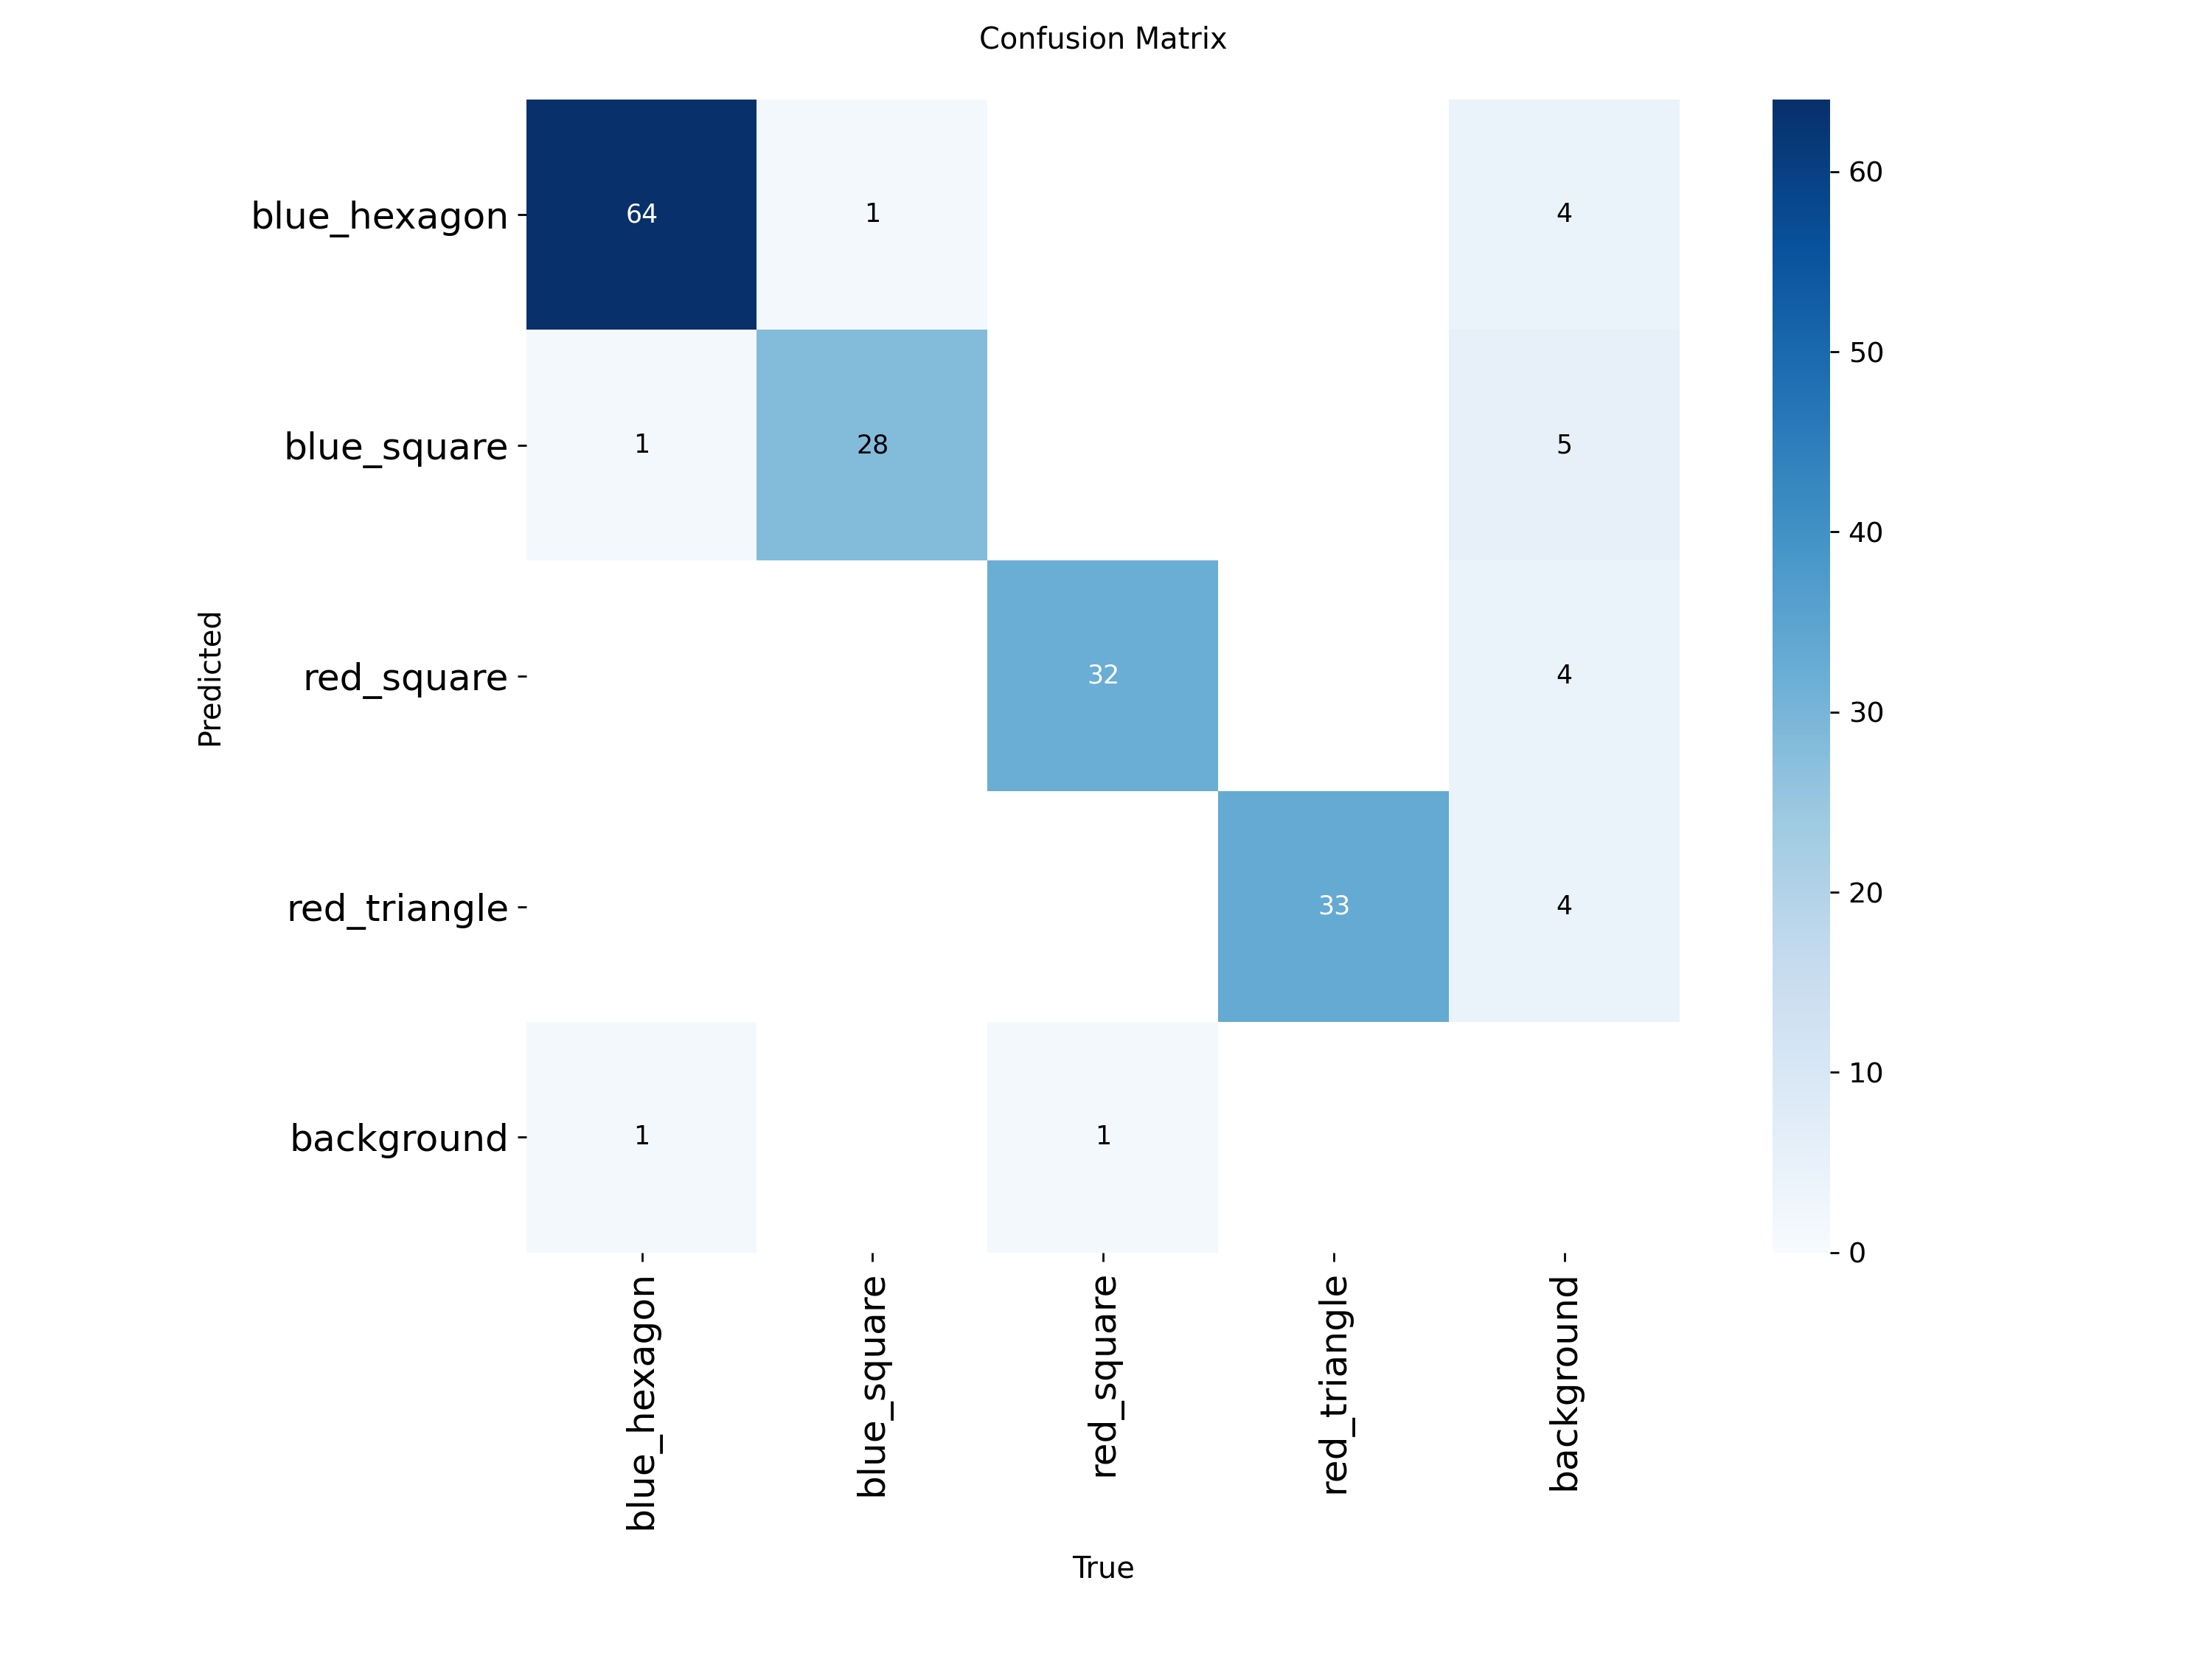


=== Eğitim Sonuç Grafikleri (Loss & mAP) ===


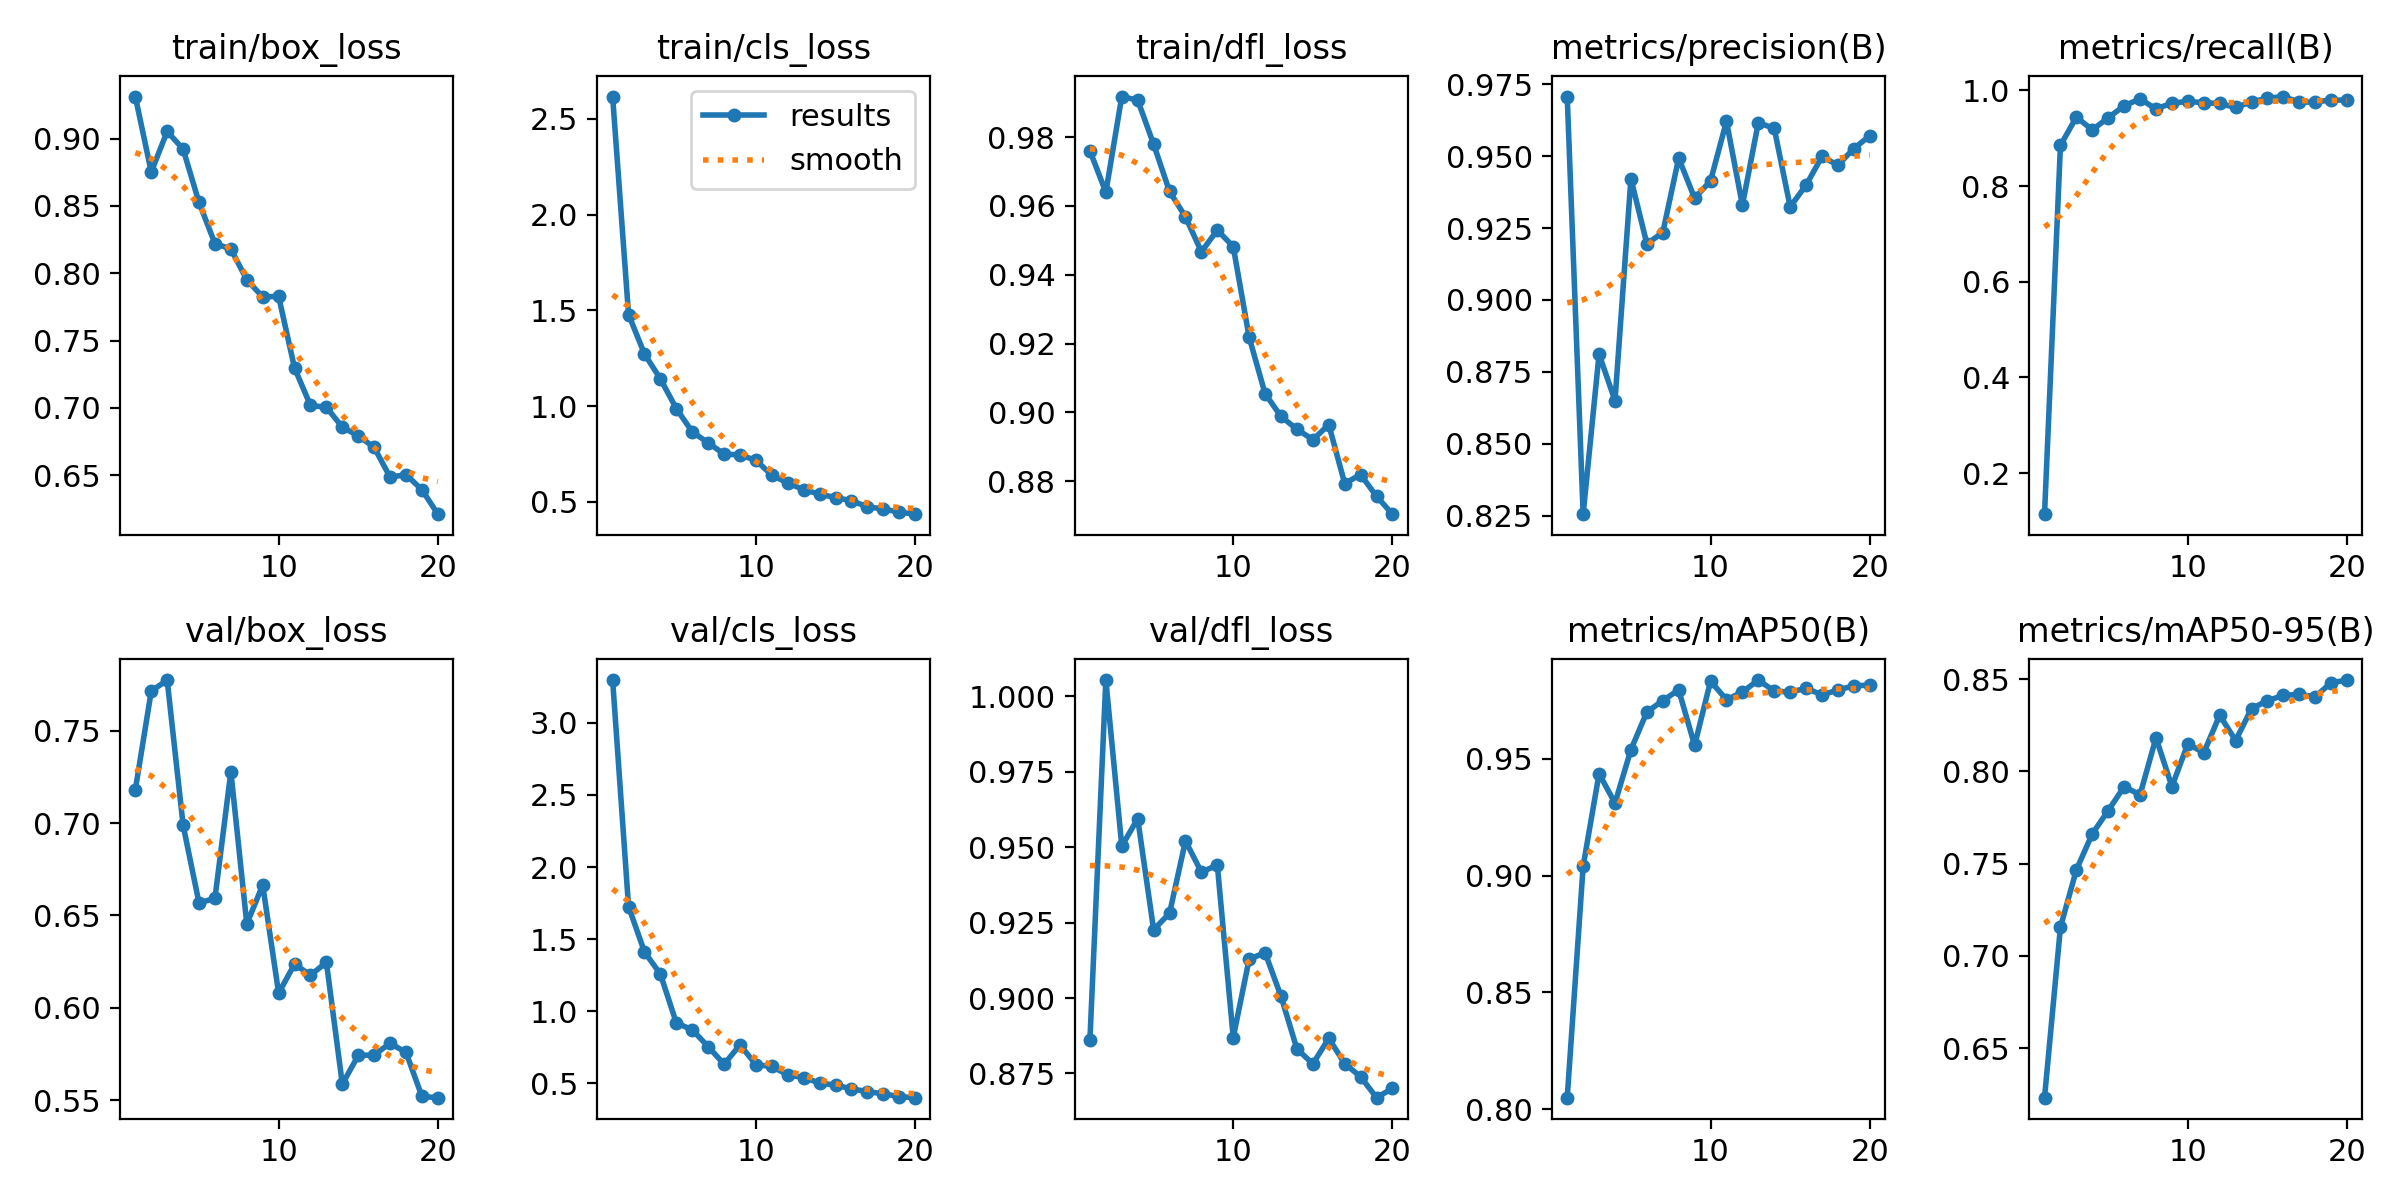


=== F1 Skoru Eğrisi ===


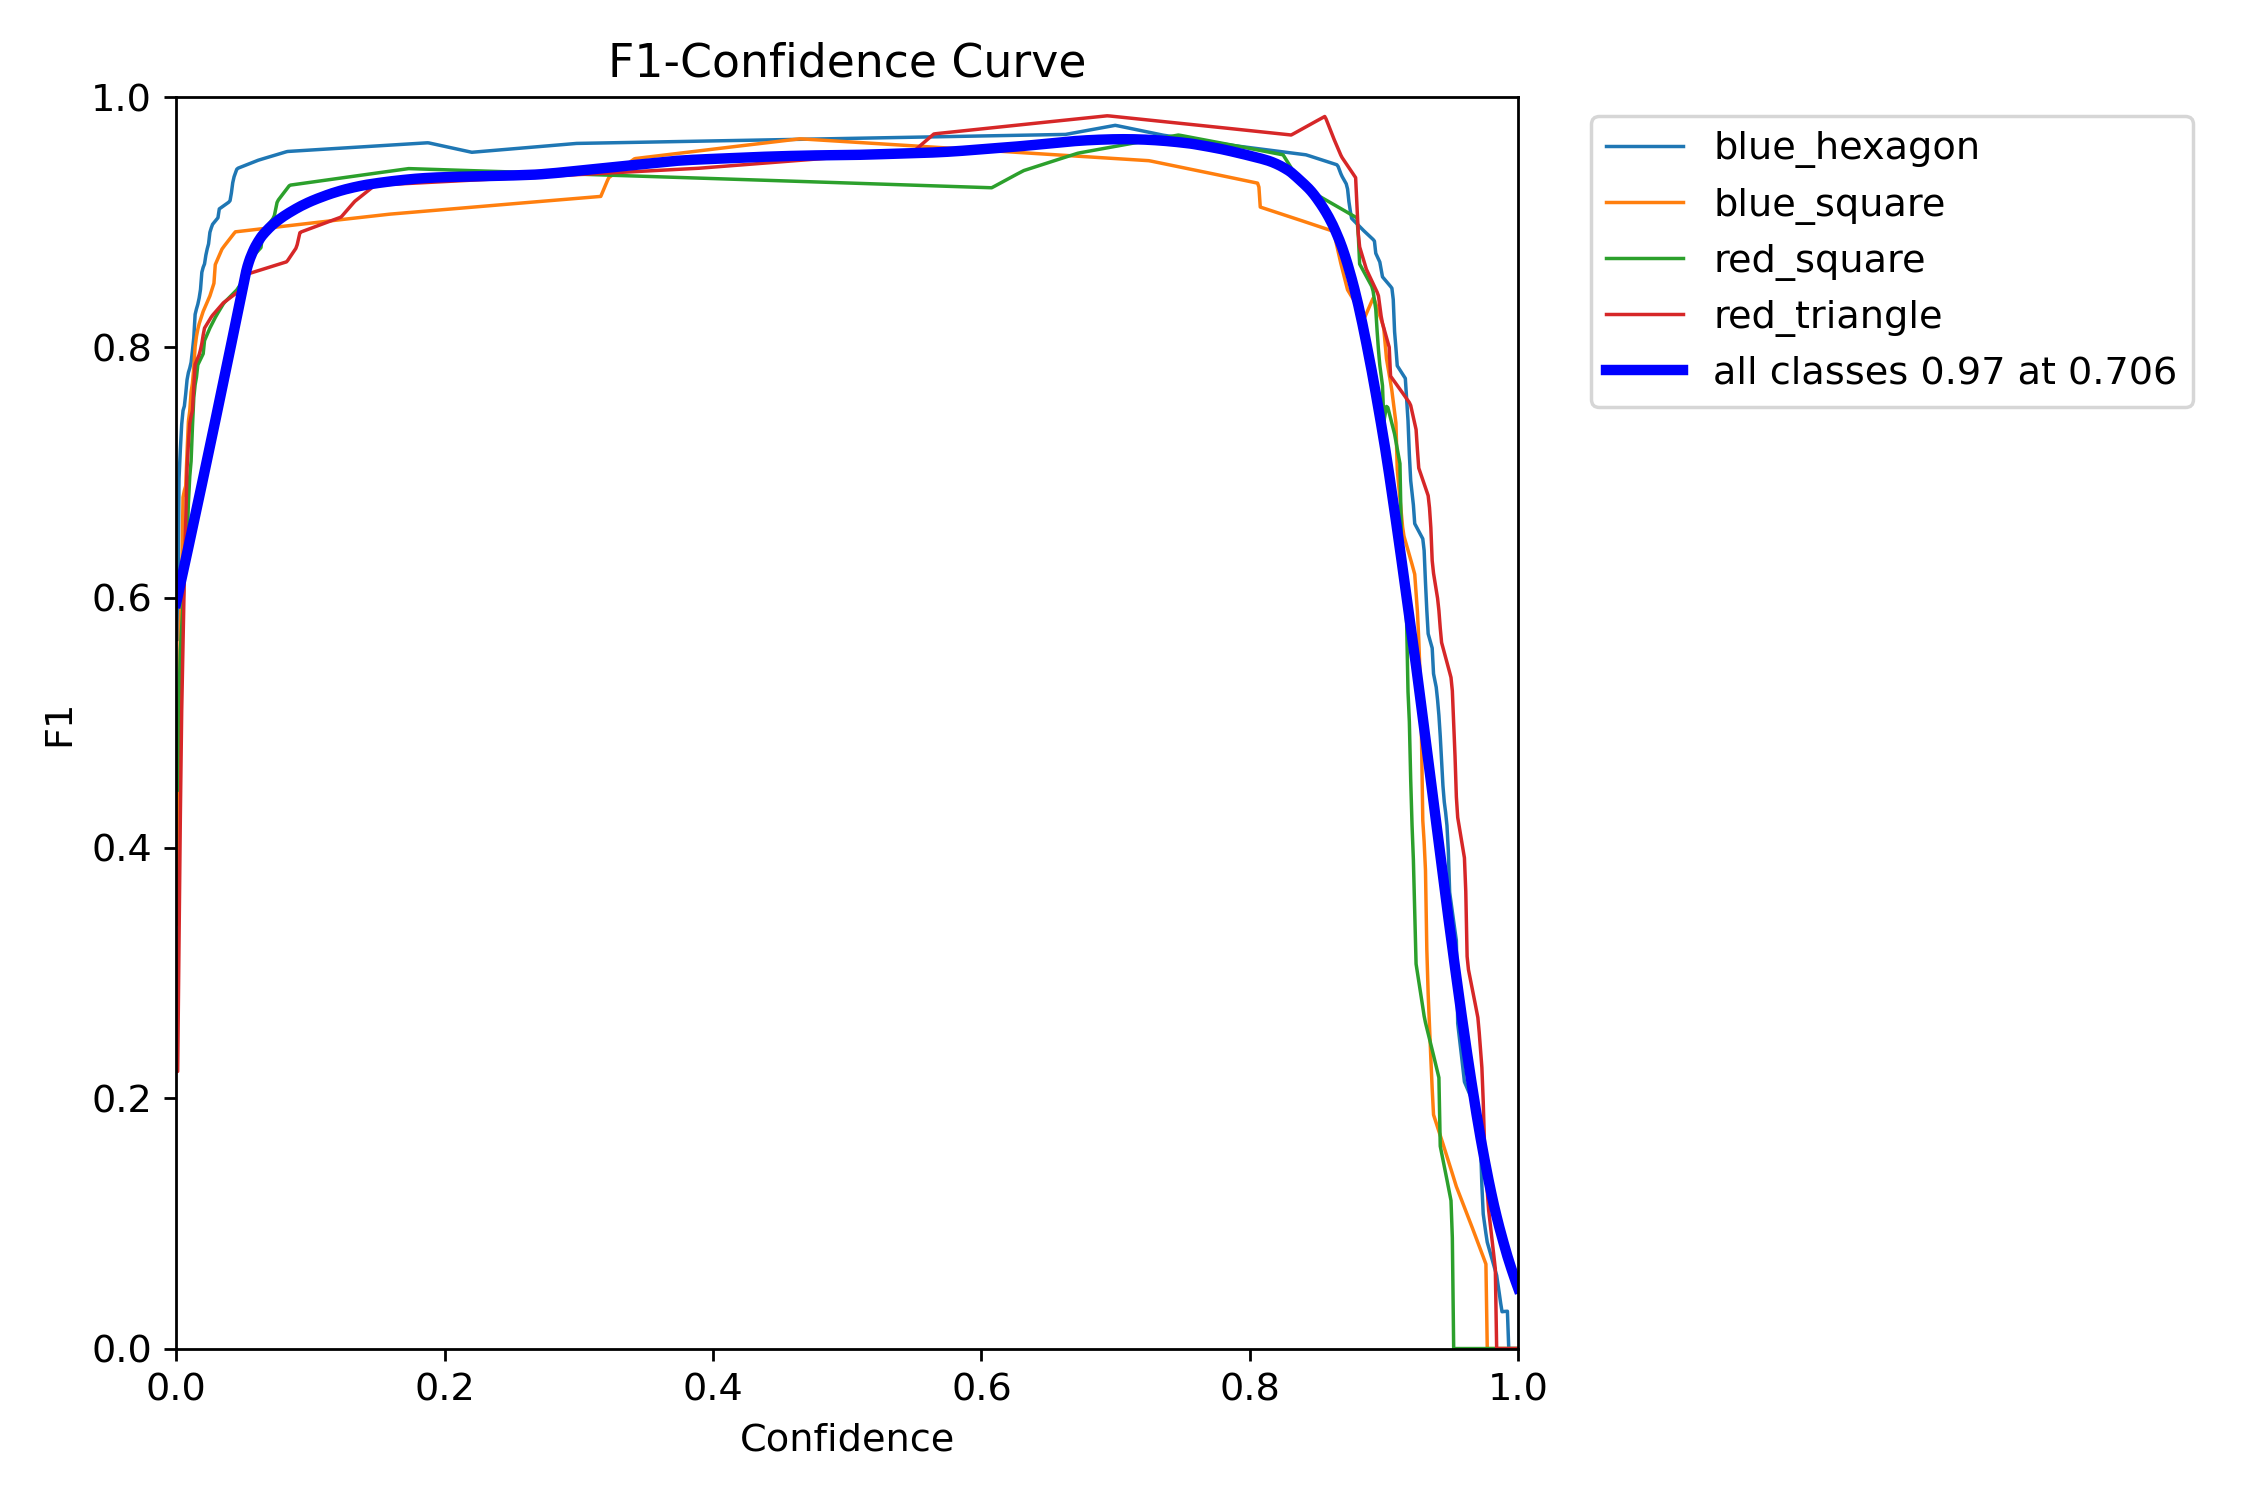

In [1]:
from IPython.display import Image, display  # IPython'dan Image ve display fonksiyonlarını içe aktar (notebook'ta görüntü göstermek için)
import os  # Dosya ve klasör yolu işlemleri için os modülünü içe aktar

# Eğitim sonuçlarının kaydedildiği klasör yolunu tanımla
results_folder = 'runs/detect/yoda_modeli2'  # YOLO modelinin eğitim sonuçlarının bulunduğu klasör yolu

# ===== KARMAŞIKLIK MATRİSİ =====
print("=== Karmaşıklık Matrisi (Confusion Matrix) ===")  # Karmaşıklık matrisi başlığını ekrana yazdır
display(Image(filename=os.path.join(results_folder, 'confusion_matrix.png'), width=600))  # Karmaşıklık matrisi görüntüsünü 600 piksel genişliğinde göster

# ===== EĞİTİM SONUÇ GRAFİKLERİ =====
print("\n=== Eğitim Sonuç Grafikleri (Loss & mAP) ===")  # Eğitim grafikleri başlığını yeni satırda ekrana yazdır
display(Image(filename=os.path.join(results_folder, 'results.png'), width=800))  # Loss ve mAP grafiklerini 800 piksel genişliğinde göster

# ===== F1 SKORU EĞRİSİ =====
print("\n=== F1 Skoru Eğrisi ===")  # F1 skoru başlığını yeni satırda ekrana yazdır
display(Image(filename=os.path.join(results_folder, 'BoxF1_curve.png'), width=600))  # F1 skoru eğrisi grafiğini 600 piksel genişliğinde göster

## Modelin Test Edilmesi ve Görselleştirme
Eğitilen modelin başarısını gözlemlemek için, modelin daha önce hiç görmediği **Test veri setinden** rastgele bir görüntü seçilmiştir.

Aşağıdaki görselleştirmede:
* **Sol Tarafta:** Modele girdi olarak verilen ham, orijinal drone görüntüsü,
* **Sağ Tarafta:** Modelin bu görüntü üzerinde tespit ettiği nesneleri (Bounding Box) ve güven skorlarını içeren sonuç görüntüsü yan yana sunulmuştur.

Görselleştirme başlatılıyor...
Seçilen Resim: 28_Temmuz_Ucus_2_3_frame_0996_jpg.rf.c12a6ac4d1439f80b1cda61c0a14b1f5.jpg
Çizim yapıldı, ekrana veriliyor...


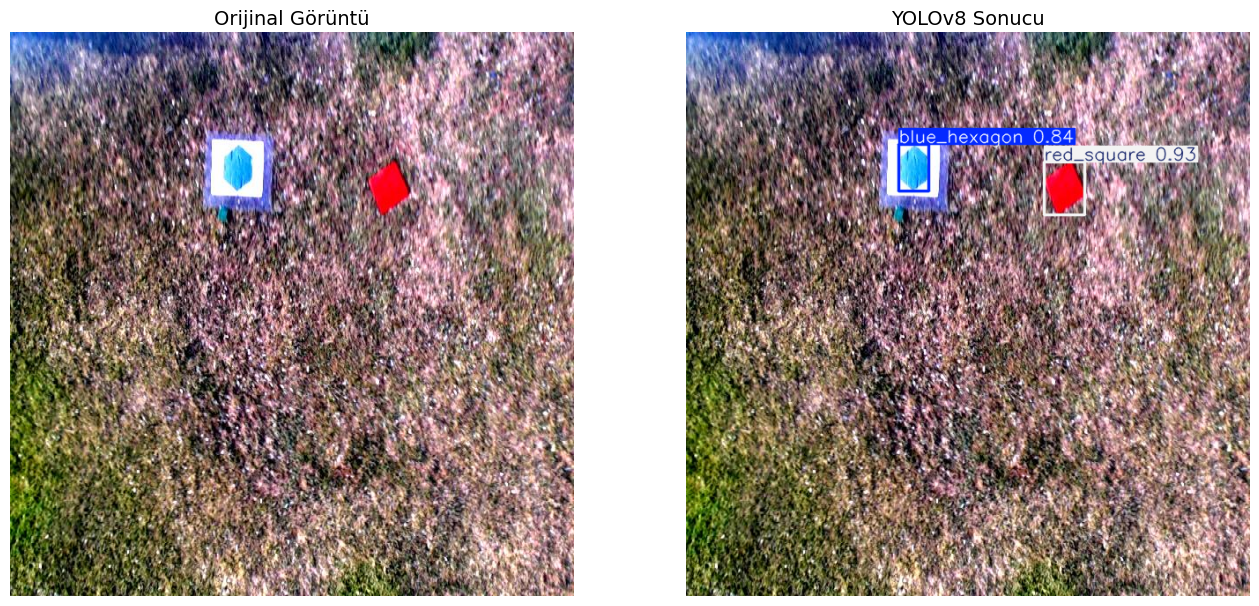

In [13]:
from ultralytics import YOLO  # Ultralytics YOLO kütüphanesinden YOLO modelini içe aktar
import matplotlib.pyplot as plt  # Grafik çizimi için matplotlib.pyplot kütüphanesini içe aktar
import cv2  # Görüntü işleme için OpenCV kütüphanesini içe aktar
import os  # Dosya ve klasör işlemleri için os modülünü içe aktar
import random  # Rastgele seçim yapmak için random modülünü içe aktar
import numpy as np  # Sayısal işlemler için numpy kütüphanesini içe aktar
 
print("Görselleştirme başlatılıyor...")  # İşlemin başladığını konsola yazdır
 
# --- AYARLAR --- 
test_folder = r'C:/Users/aydin/Desktop/Yazılım/Git/Aydin_Alizade_YODA_IHA_YAZILIM/Odev_5/yoda_odevlendirme_veriseti.yolov8/test/images'  # Test görüntülerinin bulunduğu klasör yolunu tanımla
model_path = 'runs/detect/yoda_modeli2/weights/best.pt'  # Eğitilmiş YOLO modelinin ağırlık dosyasının yolunu tanımla
 
# --- İŞLEM --- 
model = YOLO(model_path)  # Belirtilen yoldaki eğitilmiş YOLO modelini yükle
 
# Rastgele resim seç 
test_images = [img for img in os.listdir(test_folder) if img.endswith(('.jpg', '.png'))]  # Test klasöründeki tüm .jpg ve .png uzantılı dosyaları listele
random_image_name = random.choice(test_images)  # Listeden rastgele bir resim adı seç
image_path = os.path.join(test_folder, random_image_name)  # Seçilen resmin tam yolunu oluştur (klasör yolu + dosya adı)
 
print(f"Seçilen Resim: {random_image_name}")  # Seçilen resmin adını konsola yazdır
 
# Tahmin yap 
results = model.predict(image_path, conf=0.5, verbose=False)  # Model ile seçilen görüntü üzerinde nesne tespiti yap (güven eşiği 0.5)
 
# Resimleri hazırla 
img_orig_bgr = cv2.imread(image_path)  # Orijinal görüntüyü OpenCV ile oku (BGR formatında gelir)
img_orig_rgb = cv2.cvtColor(img_orig_bgr, cv2.COLOR_BGR2RGB)  # BGR formatındaki orijinal görüntüyü RGB formatına çevir (matplotlib RGB kullanır)
 
img_res_bgr = results[0].plot()  # Tahmin sonuçlarını görüntü üzerine çiz (bounding box'lar ve etiketler eklenir, BGR formatında döner)
img_res_rgb = cv2.cvtColor(img_res_bgr, cv2.COLOR_BGR2RGB)  # BGR formatındaki sonuç görüntüsünü RGB formatına çevir
 
# --- ÇİZDİRME --- 
plt.figure(figsize=(16, 8))  # 16x8 inç boyutunda yeni bir grafik figürü oluştur
 
# Sol (Orijinal) 
plt.subplot(1, 2, 1)  # 1 satır, 2 sütunluk düzende 1. pozisyonu seç (sol taraf)
plt.imshow(img_orig_rgb)  # Orijinal RGB görüntüsünü göster
plt.title("Orijinal Görüntü", fontsize=14)  # Sol taraftaki görüntüye başlık ekle
plt.axis('off')  # Eksen çizgilerini ve sayıları gizle
 
# Sağ (Tahmin) 
plt.subplot(1, 2, 2)  # 1 satır, 2 sütunluk düzende 2. pozisyonu seç (sağ taraf)
plt.imshow(img_res_rgb)  # Tahmin sonuçlarının çizildiği RGB görüntüsünü göster
plt.title("YOLOv8 Sonucu", fontsize=14)  # Sağ taraftaki görüntüye başlık ekle
plt.axis('off')  # Eksen çizgilerini ve sayıları gizle
 
print("Çizim yapıldı, ekrana veriliyor...")  # Çizim işleminin tamamlandığını konsola yazdır
plt.show()  # Hazırlanan grafiği ekranda göster